Import 

In [23]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import string
import time

import os
import warnings
import joblib

In [ ]:
df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

df_fake["label"] = 0
df_true["label"] = 1

df = pd.concat([df_fake, df_true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Fake news samples: {df['label'].value_counts()[0]}")
print(f"True news samples: {df['label'].value_counts()[1]}")

df.head(5)


Dataset shape: (44898, 5)
Fake news samples: 23481
True news samples: 21417


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [ ]:
print(f"Data types:\n{df.dtypes}")
print(f"Missing values:\n{df.isnull().sum()}")

Data types:
title      object
text       object
subject    object
date       object
label       int64
dtype: object
Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


Exploratory Data Analysis

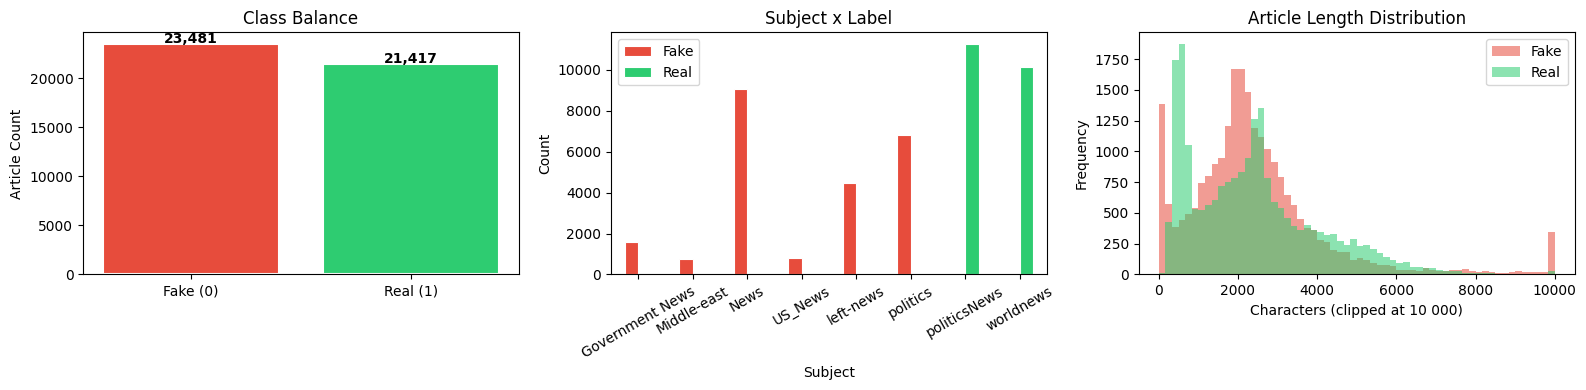

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df["label"].value_counts()
axes[0].bar(["Fake (0)", "Real (1)"], counts.values,
            color=["#E74C3C", "#2ECC71"], edgecolor="white", linewidth=1.5)
axes[0].set_title("Class Balance")
axes[0].set_ylabel("Article Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontweight="bold")

subj = df.groupby(["subject", "label"]).size().unstack(fill_value=0)
subj.plot(kind="bar", ax=axes[1], color=["#E74C3C", "#2ECC71"],
          edgecolor="white", linewidth=0.8)
axes[1].set_title("Subject x Label")
axes[1].set_xlabel("Subject")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(["Fake", "Real"])

df["text_len"] = df["text"].fillna("").apply(len)
for lbl, color, name in [(0, "#E74C3C", "Fake"), (1, "#2ECC71", "Real")]:
    subset = df.loc[df["label"] == lbl, "text_len"]
    axes[2].hist(subset.clip(upper=10_000), bins=60,
                 alpha=0.55, color=color, label=name)
axes[2].set_title("Article Length Distribution")
axes[2].set_xlabel("Characters (clipped at 10 000)")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches="tight")
plt.show()

Cleaning data

In [ ]:
_RE_URL       = re.compile(r"https?://\S+|www\.\S+")
_RE_MENTION   = re.compile(r"@\w+")
_RE_HASHTAG   = re.compile(r"#\w+")
_RE_REUTERS   = re.compile(r"^.*?\(reuters\)\s*[-–]?\s*", re.IGNORECASE)
_RE_BRACKETS  = re.compile(r"\[.*?\]|\(.*?\)")
_RE_HTML      = re.compile(r"<[^>]+>|&\w+;")
_RE_NONALPHA  = re.compile(r"[^a-z\s]")
_RE_SPACES    = re.compile(r"\s+")

def preprocessing(text : str) -> str  :
    if pd.isna(text):
        return ""
    text = text.lower()
    text = _RE_URL.sub(" ", text)
    text = _RE_MENTION.sub(" ", text)
    text = _RE_HASHTAG.sub(" ", text)
    text = _RE_REUTERS.sub(" ", text)
    text = _RE_BRACKETS.sub(" ", text)
    text = _RE_HTML.sub(" ", text)
    text = _RE_NONALPHA.sub(" ", text)
    text = _RE_SPACES.sub(" ", text).strip()

    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    text = " ".join(cleaned_tokens)
    return text


In [ ]:
df["combined_raw"] = df["title"].fillna("") + " " + df["text"].fillna("")

df["combined_clean"] = df["combined_raw"].apply(preprocessing)

before = len(df)
df = df[df["combined_clean"].str.strip().ne("")].reset_index(drop=True)
print(f"   Dropped {before - len(df)} empty rows after cleaning. Remaining: {len(df):,}")

   Dropped 9 empty rows after cleaning. Remaining: 44,889


In [7]:
X = df["combined_clean"]
y = df["label"]

print(f"Feature matrix input: {len(X):,} samples")
print(f"Label distribution:\nFake: {y.value_counts()[0]:,}\nReal: {y.value_counts()[1]:,}")

Feature matrix input: 44,889 samples
Label distribution:
Fake: 23,472
Real: 21,417


Data split 80/20 and pipeline

In [8]:
vectorizer = TfidfVectorizer(min_df=2, ngram_range=(1, 2))
a = vectorizer.fit_transform(X)
print(len(vectorizer.vocabulary_))

1512604


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.80, random_state=42, stratify=y)

feature_sum = 100000

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        sublinear_tf=True,
        ngram_range=(1, 2),
        max_features=feature_sum,
        min_df=5,
        max_df=0.95,
        strip_accents="unicode",
        analyzer="word",
    )),
    ("lr", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
    ))
])

print("Pipeline stages:")
for name, step in pipeline.steps:
    print(f"  [{name}]  {type(step).__name__}")

Pipeline stages:
  [tfidf]  TfidfVectorizer
  [lr]  LogisticRegression


Cross-validation

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy" : "accuracy",
    "f1"       : "f1",
    "recall"   : "recall",
    "precision": "precision",
}

print(f"  Running 5-fold cross-validation on the training set with max feature ({feature_sum:,}) …")
t0 = time.time()

cv_results = cross_validate(
    pipeline,
    X_train, y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True,
)

elapsed = time.time() - t0
print(f"   Done in {elapsed:.1f}s\n")

cv_df = pd.DataFrame({
    "Fold"      : range(1, 6),
    "Accuracy"  : cv_results["test_accuracy"],
    "F1"        : cv_results["test_f1"],
    "Recall"    : cv_results["test_recall"],
    "Precision" : cv_results["test_precision"],
})
cv_df = cv_df.set_index("Fold")

print("=== Cross-Validation Results (Validation Folds) ===")
print(cv_df.round(4).to_string())
print()
print("=== Mean ± Std ===")
summary = pd.DataFrame({
    "Mean" : cv_df.mean(),
    "Std"  : cv_df.std(),
})
print(summary.round(4).to_string())


  Running 5-fold cross-validation on the training set with max feature (100,000) …
   Done in 12.8s

=== Cross-Validation Results (Validation Folds) ===
      Accuracy      F1  Recall  Precision
Fold                                     
1       0.9766  0.9757  0.9825     0.9689
2       0.9783  0.9773  0.9778     0.9767
3       0.9749  0.9739  0.9813     0.9667
4       0.9749  0.9739  0.9825     0.9656
5       0.9805  0.9796  0.9836     0.9757

=== Mean ± Std ===
             Mean     Std
Accuracy   0.9771  0.0024
F1         0.9761  0.0024
Recall     0.9816  0.0022
Precision  0.9707  0.0052


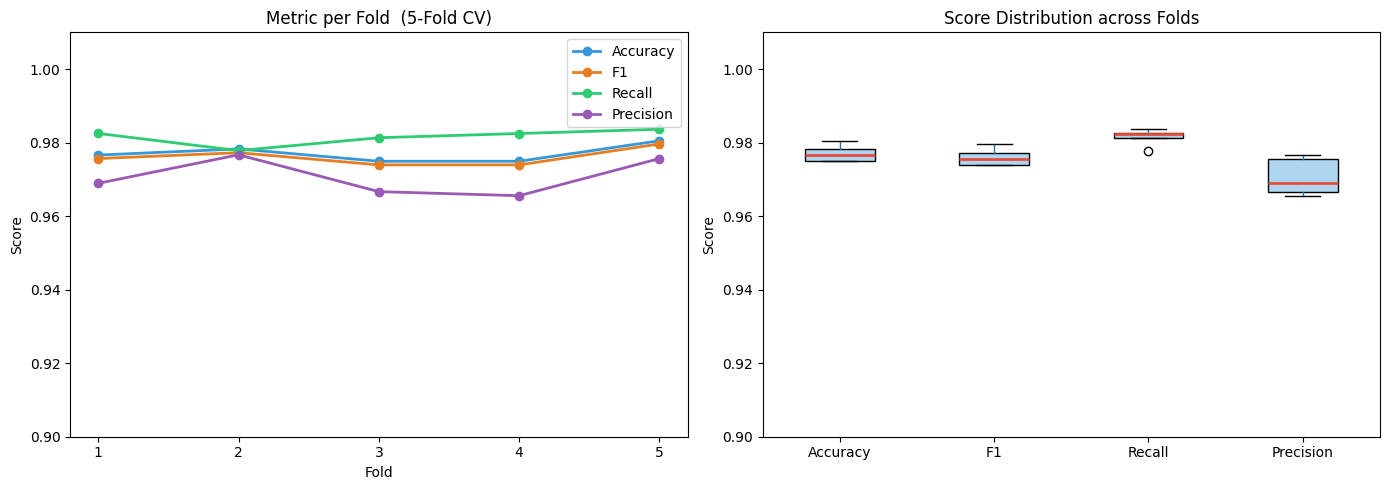

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_plot = ["Accuracy", "F1", "Recall", "Precision"]
colors       = ["#3498DB", "#E67E22", "#2ECC71", "#9B59B6"]
for metric, color in zip(metrics_plot, colors):
    axes[0].plot(cv_df.index, cv_df[metric], marker="o",
                 label=metric, color=color, linewidth=2)
axes[0].set_title("Metric per Fold  (5-Fold CV)")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.90, 1.01)
axes[0].set_xticks(range(1, 6))
axes[0].legend()

cv_df.boxplot(ax=axes[1], grid=False, patch_artist=True,
              boxprops=dict(facecolor="#AED6F1"),
              medianprops=dict(color="#E74C3C", linewidth=2))
axes[1].set_title("Score Distribution across Folds")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0.90, 1.01)

plt.tight_layout()
plt.savefig(f"cv_results_{feature_sum:,}.png", bbox_inches="tight")
plt.show()

In [ ]:
print("Fitting final model on the entire training set …")
t0 = time.time()
pipeline.fit(X_train, y_train)
elapsed = time.time() - t0
print(f"   Done in {elapsed:.1f}s\n")

vocab_size = len(pipeline.named_steps["tfidf"].vocabulary_)
print(f"   TF-IDF vocabulary size : {vocab_size:,} features")

Fitting final model on the entire training set …
   Done in 7.3s

   TF-IDF vocabulary size : 62,100 features


Save model to joblib

In [25]:
os.makedirs("models", exist_ok=True)
model_path = f"models/logistic_regression.joblib"
joblib.dump(pipeline, model_path)

['models/logistic_regression.joblib']

Evaluation

In [26]:
y_pred = pipeline.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)

print("=" * 45)
print(f"{'METRIC':<20} {'SCORE':>10}")
print("=" * 45)
print(f"{'Accuracy':<20} {acc:>10.4f}")
print(f"{'F1 Score':<20} {f1:>10.4f}")
print(f"{'Recall':<20} {rec:>10.4f}")
print(f"{'Precision':<20} {prec:>10.4f}")
print("=" * 45)
print()
print("=== Full Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["FAKE (0)", "REAL (1)"]))

METRIC                    SCORE
Accuracy                 0.9782
F1 Score                 0.9773
Recall                   0.9845
Precision                0.9703

=== Full Classification Report ===
              precision    recall  f1-score   support

    FAKE (0)       0.99      0.97      0.98     18778
    REAL (1)       0.97      0.98      0.98     17134

    accuracy                           0.98     35912
   macro avg       0.98      0.98      0.98     35912
weighted avg       0.98      0.98      0.98     35912



Confusion Matrix Visual

True  Negatives  (Fake correctly classified): 18,262
False Positives  (Fake wrongly → Real)      : 516
False Negatives  (Real wrongly → Fake)      : 266
True  Positives  (Real correctly classified): 16,868


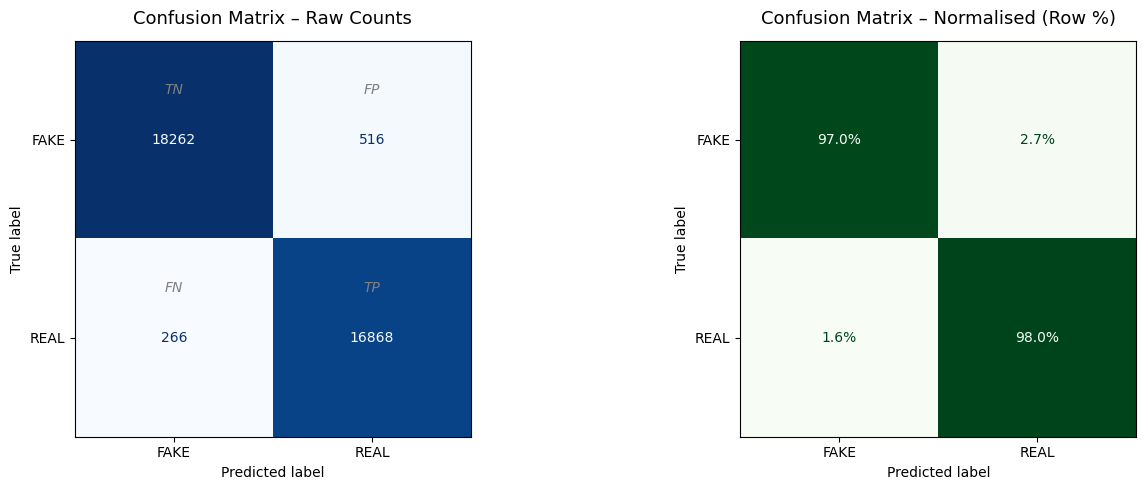

In [ ]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"True  Negatives  (Fake correctly classified): {tn:,}")
print(f"False Positives  (Fake wrongly → Real)      : {fp:,}")
print(f"False Negatives  (Real wrongly → Fake)      : {fn:,}")
print(f"True  Positives  (Real correctly classified): {tp:,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["FAKE", "REAL"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix – Raw Counts", fontsize=13, pad=12)

for (i, j), val in np.ndenumerate(cm):
    tag = {(0,0):"TN", (0,1):"FP", (1,0):"FN", (1,1):"TP"}[(i, j)]
    axes[0].text(j, i - 0.25, tag, ha="center", va="center",
                 color="grey", fontsize=10, fontstyle="italic")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_n  = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                  display_labels=["FAKE", "REAL"])
disp_n.plot(ax=axes[1], colorbar=False, cmap="Greens")
axes[1].set_title("Confusion Matrix – Normalised (Row %)", fontsize=13, pad=12)

# Format percentages
for text in axes[1].texts:
    val = float(text.get_text())
    text.set_text(f"{val*100:.1f}%")

plt.tight_layout()
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

Metrics Dashboard

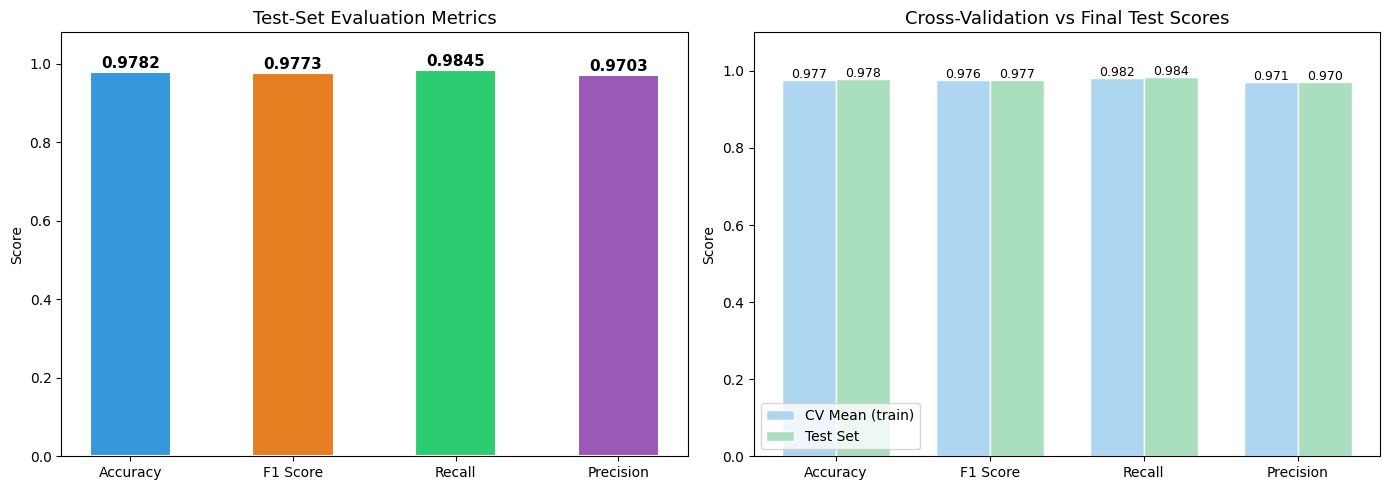

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_names  = ["Accuracy", "F1 Score", "Recall", "Precision"]
metric_values = [acc, f1, rec, prec]
bar_colors    = ["#3498DB", "#E67E22", "#2ECC71", "#9B59B6"]

bars = axes[0].bar(metric_names, metric_values, color=bar_colors,
                   edgecolor="white", linewidth=1.5, width=0.5)
axes[0].set_ylim(0, 1.08)
axes[0].set_title("Test-Set Evaluation Metrics", fontsize=13)
axes[0].set_ylabel("Score")
for bar, val in zip(bars, metric_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")

cv_means = [cv_df["Accuracy"].mean(), cv_df["F1"].mean(),
            cv_df["Recall"].mean(), cv_df["Precision"].mean()]

x = np.arange(len(metric_names))
width = 0.35
b1 = axes[1].bar(x - width/2, cv_means,  width, label="CV Mean (train)",
                 color="#AED6F1", edgecolor="white")
b2 = axes[1].bar(x + width/2, metric_values, width, label="Test Set",
                 color="#A9DFBF", edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_names)
axes[1].set_ylim(0, 1.10)
axes[1].set_title("Cross-Validation vs Final Test Scores", fontsize=13)
axes[1].set_ylabel("Score")
axes[1].legend()

for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f"{bar.get_height():.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("metrics_dashboard.png", bbox_inches="tight")
plt.show()